# Heart Disease Dataset — Complete EDA Notebook

This notebook is my mini-project for the second week of BinX AI & ML training.

**Dataset:** `heart.csv` — 1,025 patient records, 13 clinical features + 1 target label (presence of heart disease).

**Overview:** 
this mini project covers the core Steps in EDAData Inspection: 

1. Checking size, data types, and initial rows
2. Data Cleaning:
   - Finding and fixing missing values and duplicate rows.
   - Outlier Detection: Locating extreme values or noise in the data.Analysis TechniquesUnivariate Analysis: Studying one variable at a time using histograms, bar charts, or summary stats.

3. Bivariate Analysis: Comparing two variables to see how they interact using scatter plots or box plots.


# Loadig Data and libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()


Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


**Column description**

| Column | Meaning |
|---|---|
| age | age in years |
| sex | 1 = male, 0 = female |
| cp | chest pain type (0-3) |
| trestbps | resting blood pressure (mm Hg) |
| chol | serum cholesterol (mg/dl) |
| fbs | fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | resting ECG results (0-2) |
| thalach | maximum heart rate achieved |
| exang | exercise-induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise relative to rest |
| slope | slope of the peak exercise ST segment (0-2) |
| ca | number of major vessels colored by fluoroscopy (0-4) |
| thal | thalassemia result (0-3) |
| target | 1 = heart disease present, 0 = not present |

### No missing values are present in this dataset 


In [3]:
df.isnull().sum().to_frame("missing_values")


,missing_values
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## 1. Descriptive Statistics 

First we describe the center and spread of the key numeric variables: `age`, `trestbps`, `chol`, `thalach`,
and `oldpeak`. using the function
 

.describe() 


Categorical variables (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`, `target`)
are summarized separately later as counts, since mean/median are less meaningful for category codes.


In [3]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df[numeric_cols].describe()

,age,trestbps,chol,thalach,oldpeak
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512
std,9.072290,17.516718,51.59251,23.005724,1.175053
min,29.000000,94.000000,126.00000,71.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000
75%,61.000000,140.000000,275.00000,166.000000,1.800000
max,77.000000,200.000000,564.00000,202.000000,6.200000


## 2. Univariate Analysis & Outlier Detection 

### 2.1 Distributions of numeric variables


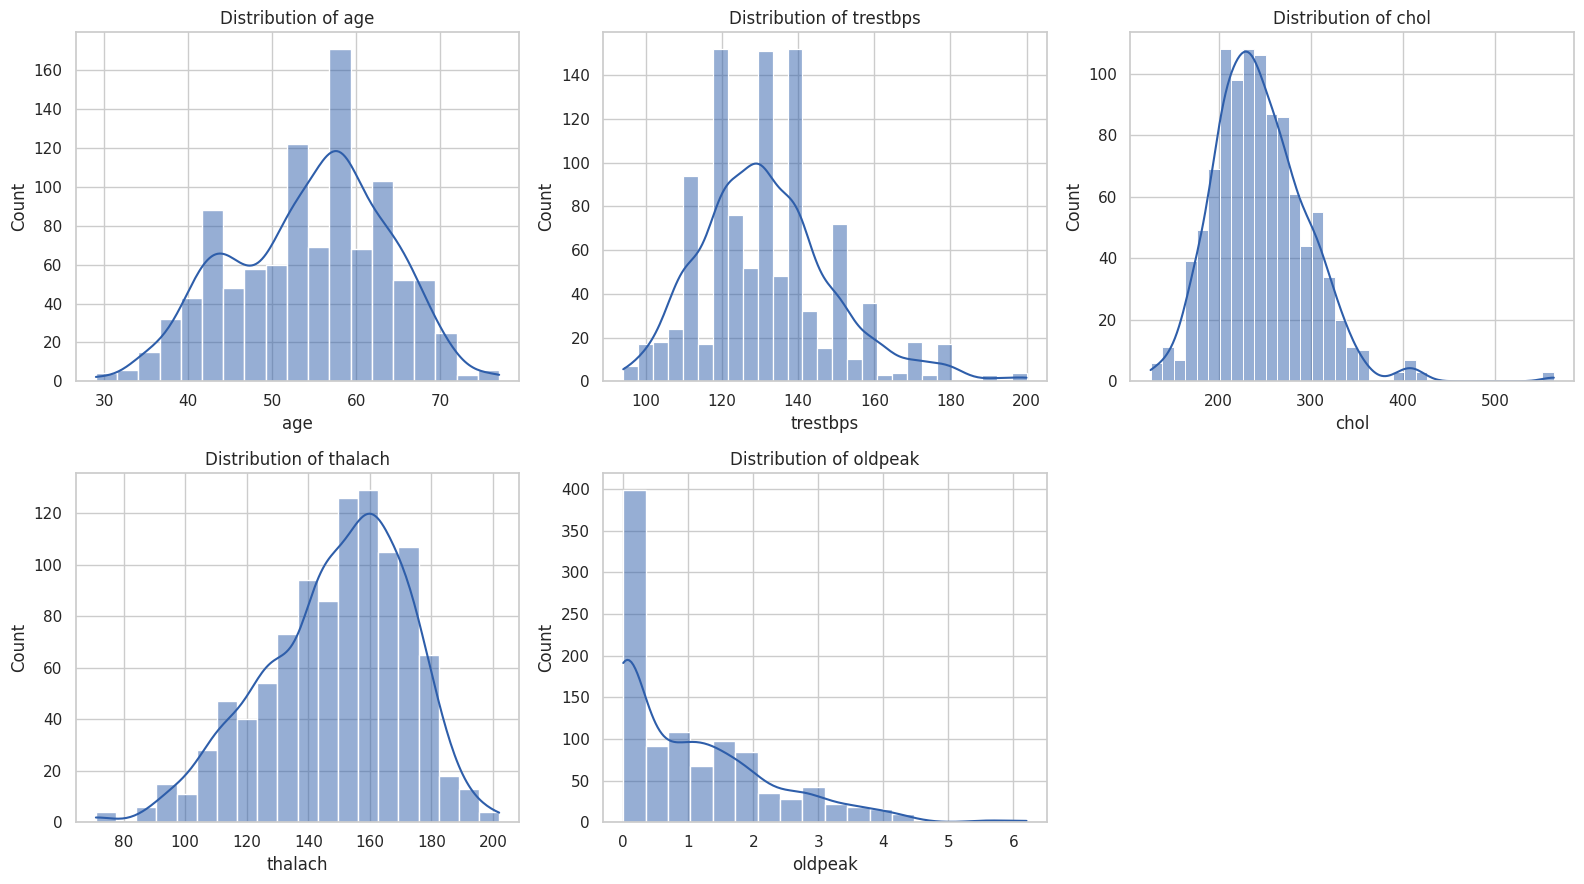

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="#2E5EAA")
    ax.set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


### 2.2 Using box plots to spot outliers 

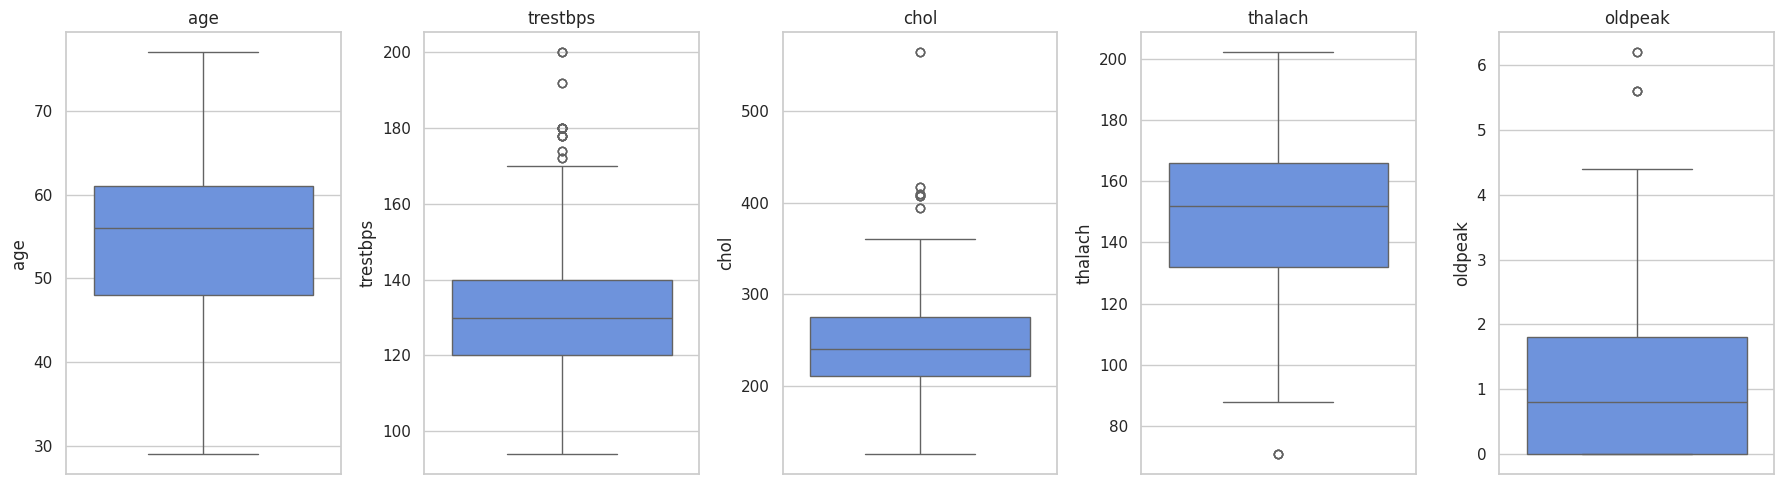

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, y=col, ax=ax, color="#5B8DEF")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**What patterns were found:**
- `chol`, `trestbps`, and `oldpeak` are right-skewed with  high-value outliers.
     > median-based summaries
  and robust scaling are more appropriate for these than mean-based ones.



### 2.3 IQR outlier detection

Applying the standard rule from Day 4: any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as a
potential outlier.


In [8]:
def iqr_outliers(data, col):
    q1, q3 = np.percentile(data[col], [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = data[(data[col] < lower) | (data[col] > upper)]
    return flagged, lower, upper

outlier_report = {}
for col in numeric_cols:
    flagged, lower, upper = iqr_outliers(df, col)
    outlier_report[col] = {"lower_bound": lower, "upper_bound": upper, "n_outliers": len(flagged)}

pd.DataFrame(outlier_report).T


,lower_bound,upper_bound,n_outliers
age,28.5,80.5,0.0
trestbps,90.0,170.0,30.0
chol,115.0,371.0,16.0
thalach,81.0,217.0,4.0
oldpeak,-2.7,4.5,7.0


### Outlier Notes

From the box plots, `chol`, `trestbps`, and `oldpeak` have the largest number of outliers. This matches what we saw earlier in the histograms, where these features were right-skewed.

These outliers don't necessarily mean the data is wrong. In a medical dataset, some patients can naturally have very high cholesterol, blood pressure, or ST depression values. So instead of removing them, we'll keep them because they may contain important information.

For future machine learning models, these features might need a more robust scaling method, such as `RobustScaler`, since it is less affected by outliers than `StandardScaler`. This allows us to reduce the impact of extreme values without losing potentially useful data.

### 2.4 Categorical variables — count plots

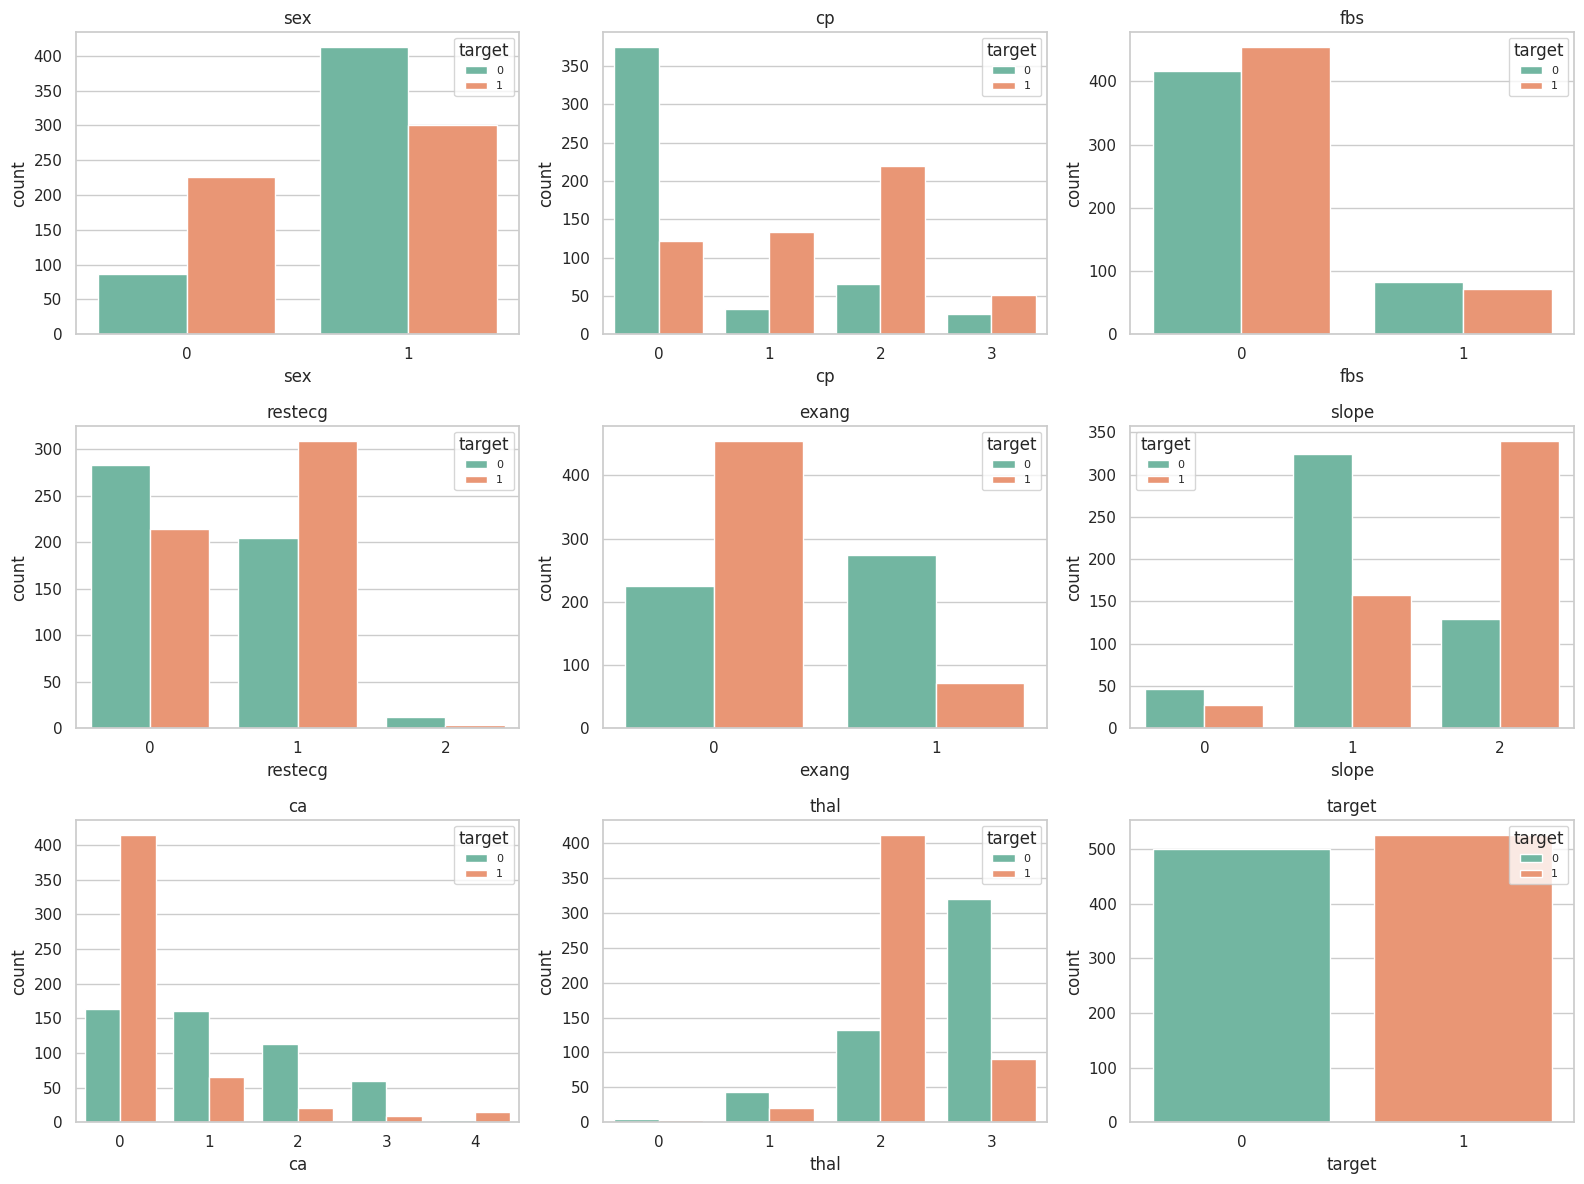

In [9]:
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue="target", ax=ax, palette="Set2")
    ax.set_title(col)
    ax.legend(title="target", fontsize=8)
plt.tight_layout()
plt.show()


### How to read these diagrams:

These categorical diagrams  are counted for their catagory and their catagory under the target lable. For example, in the sex diagram there are four bars. It's because it divided according to the target label. Meaning, we counted the men who have heart attacks and  the ones who dont seperetly. And so on with the rest 

#### **Class balance:** 

- the `target` variable  is close to balanced (roughly half the patients have heart disease), which  means that this dataset has the right ratio that is suitable for modeling .

 - `sex` is imbalanced (more male patients). **However, statistically men are more likely to have heart attacks than women,** so this might be a valid assumbtion that this dataset resembles real life portions. But we will have to make more hypothesis and calculations when generalizing this data


## 3. Bivariate Analysis 

### 3.1 Scatter plots — numeric vs numeric


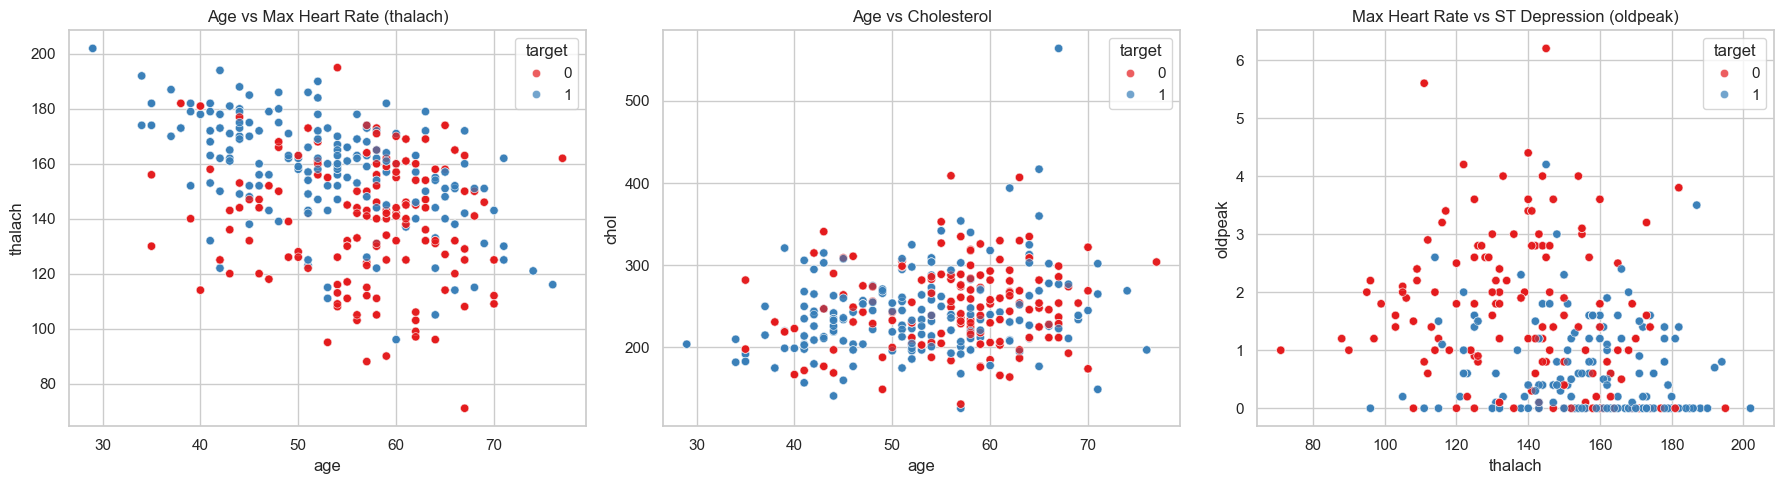

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x="age", y="thalach", hue="target", ax=axes[0], palette="Set1", alpha=0.7)
axes[0].set_title("Age vs Max Heart Rate (thalach)")

sns.scatterplot(data=df, x="age", y="chol", hue="target", ax=axes[1], palette="Set1", alpha=0.7)
axes[1].set_title("Age vs Cholesterol")

sns.scatterplot(data=df, x="thalach", y="oldpeak", hue="target", ax=axes[2], palette="Set1", alpha=0.7)
axes[2].set_title("Max Heart Rate vs ST Depression (oldpeak)")
plt.tight_layout()
plt.show()


 **most important variable pairs in the dataset:**

 - `age` vs `thalach` (Maximum Heart Rate Achieved)
    > Patients with heart disease may have lower exercise capacity, meaning they might achieve lower maximum heart rates.
    > we want to see if maximum achievable heart rate decreases as age increases.
    >
    > **There is a visibly negative linear relationship between the two columns where the maximum achievable heart rate decreases as age increases**
    >
    >                                                   Age↑⇒Maximum Heart Rate↓
    >
    > this can be measured with Pearson Correlation since it is linears 
    >
- `age` vs `chol` (Cholesterol Level)
    > -  Older patients more likely to have higher cholesterol
    > -  patients with heart disease have higher cholesterol values
    > 
    >  **There is a small positive linear relationship between the two columns where the Cholesterol increases as age increases**
    > 
    >                                                      Age↑⇒Cholesterol↑

- `thalach` vs `oldpeak` (Maximum Heart Rate vs ST Depression)
   > 
   > thalach measures exercise performance.
   > oldpeak measures ST depression caused by exercise, which is related to reduced blood flow to the heart.
   > Patients with heart disease may:
   >  >achieve lower maximum heart rates
   >  >
   >  >  have higher ST depression values
   >
   >
   >                                                        oldpeak↑⇒thalach↓
   

## 4. Correlation Analysis 

### 4.1 Correlation matrix and heatmap


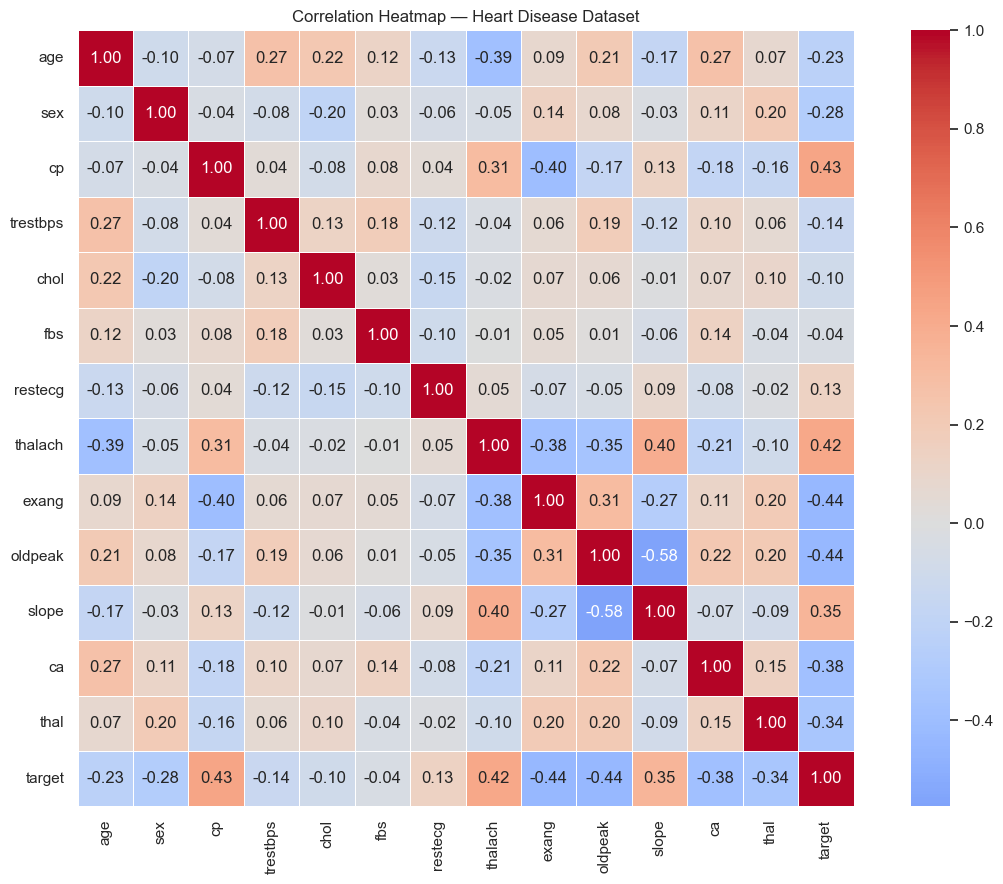

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Heart Disease Dataset")
plt.tight_layout()
plt.show()



### Summary: Strongest relationships in the dataset

Based on the correlation values and the heatmap, these are the strongest relationships I found:

1. **`cp` (chest pain), `exang` (exercise-induced angina), and `oldpeak` have the strongest relationship with the target.**
   This tells us that these features are probably the most useful for predicting whether a patient has heart disease or not. In future machine learning models, these features will likely have more influence on the prediction than many of the other variables.

2. **`thalach` (maximum heart rate) and `oldpeak` are also closely related.**
   They both describe how the heart responds during exercise. Since they show a strong relationship with the target, they are important features to keep when building prediction models. They may also work better together than individually.

3. **`age` has only a weak correlation with the target.**
   Even though older people are generally at a higher risk of heart disease, the dataset doesn't show a strong *linear* relationship between age and the target. This doesn't mean age isn't important—it just means that age alone isn't enough to make good predictions. It probably affects other features, like `thalach` or `chol`, which then contribute more directly to the prediction.

### What does this mean for future analysis?

This analysis gives us an idea of which features are likely to be the most useful when we start building machine learning models. Features with stronger relationships to the target are good candidates to keep, while features with very weak relationships may contribute less on their own.

However, we shouldn't remove weak features just because they have a low correlation. Some variables become much more useful when they are combined with others, and many machine learning models can learn those interactions automatically.

Overall, this step helps us understand the data better and gives us a good starting point for feature selection and model building in the next stages.